In [1]:
import pandas as pd
import requests
from pycoingecko import CoinGeckoAPI
import yfinance as yf
from datetime import datetime, timedelta
import os

cg = CoinGeckoAPI()
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# Get current price of BTC, ETH, SOL
prices = cg.get_price(
    ids=['bitcoin', 'ethereum', 'solana'],
    vs_currencies='usd',
    include_24hr_change=True
)

for coin, data in prices.items():
    print(f"{coin}: ${data['usd']:,}  |  24h change: {data['usd_24h_change']:.2f}%")

bitcoin: $66,653  |  24h change: 1.08%
ethereum: $2,009.23  |  24h change: 1.40%
solana: $82.65  |  24h change: -0.02%


In [3]:
def fetch_crypto_history(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    
    # Flatten MultiIndex columns (new yfinance versions return tuples)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0].lower() for col in df.columns]
    else:
        df.columns = [c.lower() for c in df.columns]
    
    df.index.name = 'date'
    return df

btc = fetch_crypto_history('BTC-USD', '2022-01-01', '2024-12-31')
print(btc.shape)
btc.tail()

[*********************100%***********************]  1 of 1 completed

(1095, 5)


,close,high,low,open,volume
date,,,,,
2024-12-26,95795.515625,99884.570312,95137.882812,99297.695312,47054980873
2024-12-27,94164.859375,97294.843750,93310.742188,95704.976562,52419934565
2024-12-28,95163.929688,95525.898438,94014.289062,94160.187500,24107436185
2024-12-29,93530.226562,95174.875000,92881.789062,95174.054688,29635885267
2024-12-30,92643.210938,94903.320312,91317.132812,93527.195312,56188003691


In [4]:
btc.to_csv('../data/btc_raw.csv')

# Do the same for ETH and SOL
eth = fetch_crypto_history('ETH-USD', '2022-01-01', '2024-12-31')
sol = fetch_crypto_history('SOL-USD', '2022-01-01', '2024-12-31')

eth.to_csv('../data/eth_raw.csv')
sol.to_csv('../data/sol_raw.csv')

print("Data saved ✓")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Data saved ✓


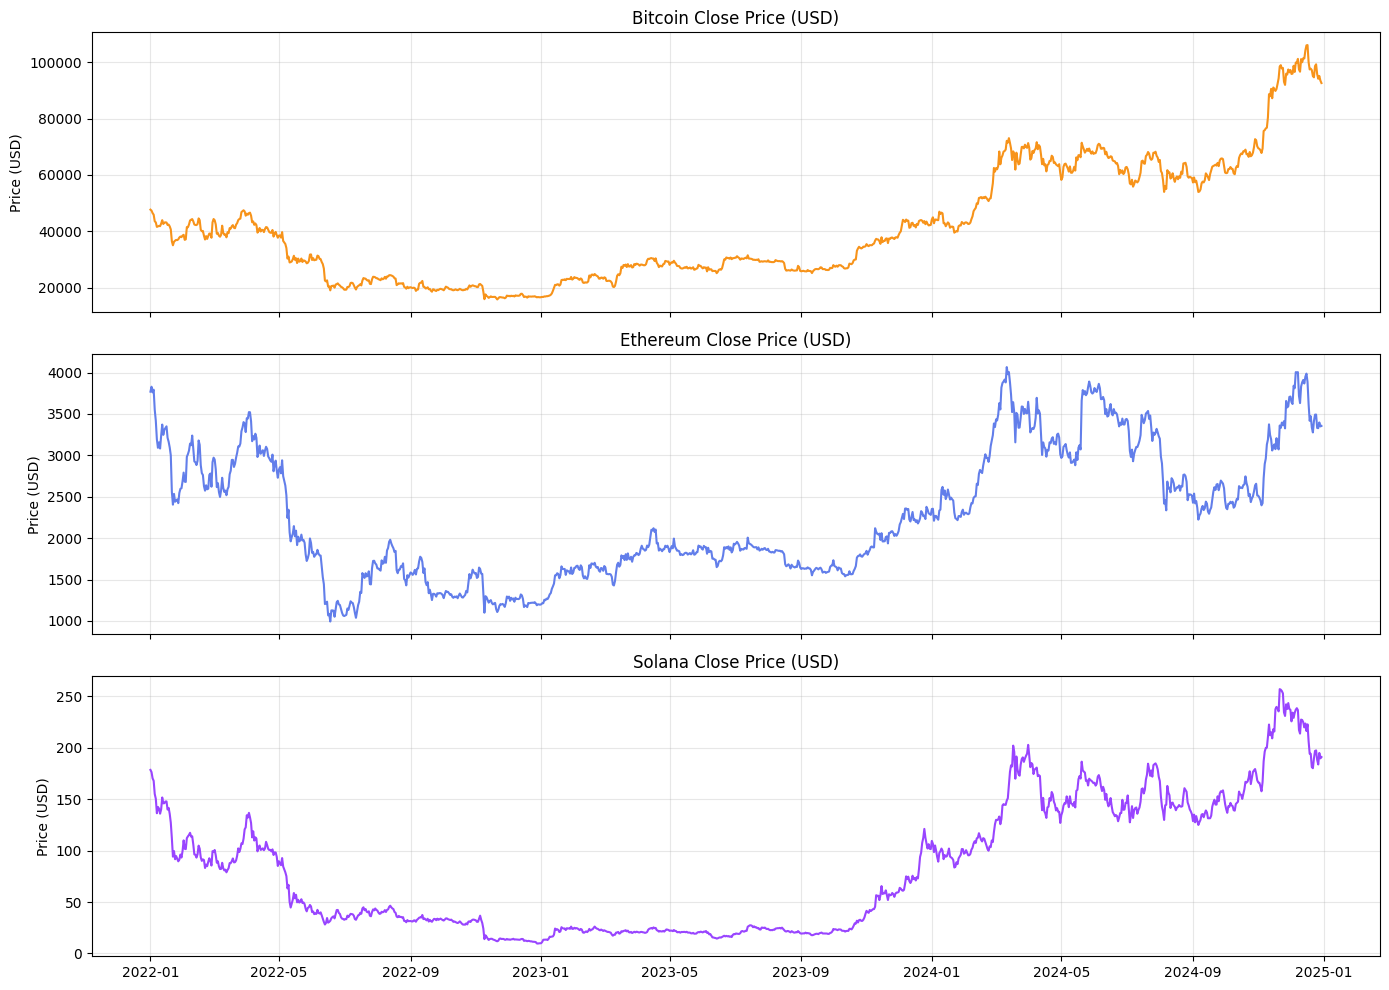

Plot saved ✓


In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for ax, df, name, color in zip(
    axes,
    [btc, eth, sol],
    ['Bitcoin', 'Ethereum', 'Solana'],
    ['#F7931A', '#627EEA', '#9945FF']
):
    ax.plot(df.index, df['close'], color=color, linewidth=1.5)
    ax.set_title(f'{name} Close Price (USD)', fontsize=12)
    ax.set_ylabel('Price (USD)')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/price_overview.png', dpi=150)
plt.show()
print("Plot saved ✓")